In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")


customers = pd.read_csv("olist_customers_dataset.csv.zip")
orders = pd.read_csv("olist_orders_dataset.csv.zip")
order_items = pd.read_csv("olist_order_items_dataset.csv.zip")
products = pd.read_csv("olist_products_dataset.csv.zip")
payments = pd.read_csv("olist_order_payments_dataset.csv.zip")
reviews = pd.read_csv("olist_order_reviews_dataset.csv.zip")
sellers = pd.read_csv("olist_sellers_dataset.csv")
translation = pd.read_csv("product_category_name_translation.csv")

In [ ]:
products["product_category_name"] = products["product_category_name"].fillna("Unknown")

reviews["review_comment_title"] = reviews["review_comment_title"].fillna("No Title")
reviews["review_comment_message"] = reviews["review_comment_message"].fillna("No Comment")

Which states have the highest number of customers?

<Axes: title={'center': 'Top 10 States by Customers'}, xlabel='customer_state'>

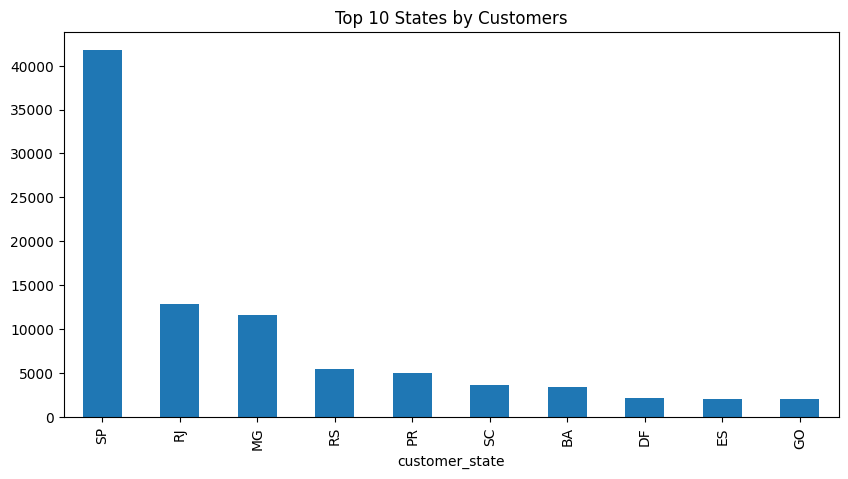

In [ ]:
state = customers["customer_state"].value_counts().head(10)

state.plot(kind="bar", figsize=(10,5), title="Top 10 States by Customers")

What percentage of orders are delivered, canceled, or in progress?

<Axes: title={'center': 'Order Status Distribution'}, xlabel='order_status'>

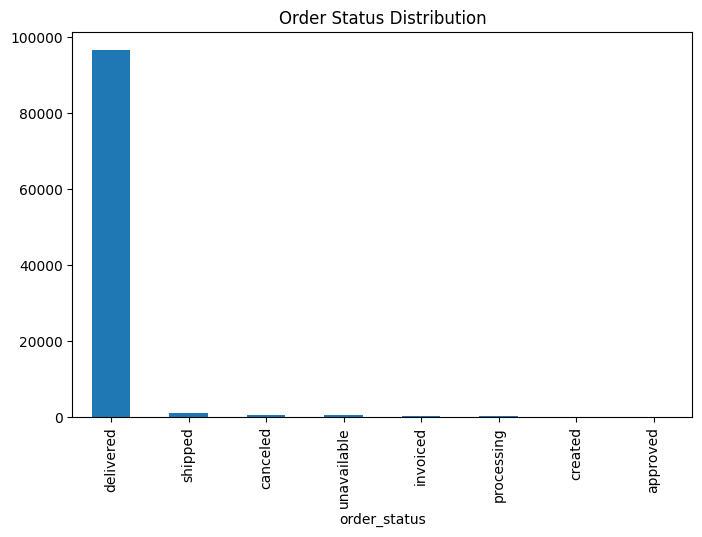

In [ ]:
orders["order_status"].value_counts().plot(
    kind="bar",
    figsize=(8,5),
    title="Order Status Distribution"
)

Monthly Order Trend

In [ ]:
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)
orders["Month"] = orders["order_purchase_timestamp"].dt.to_period("M")

<Axes: title={'center': 'Monthly Orders'}, xlabel='Month'>

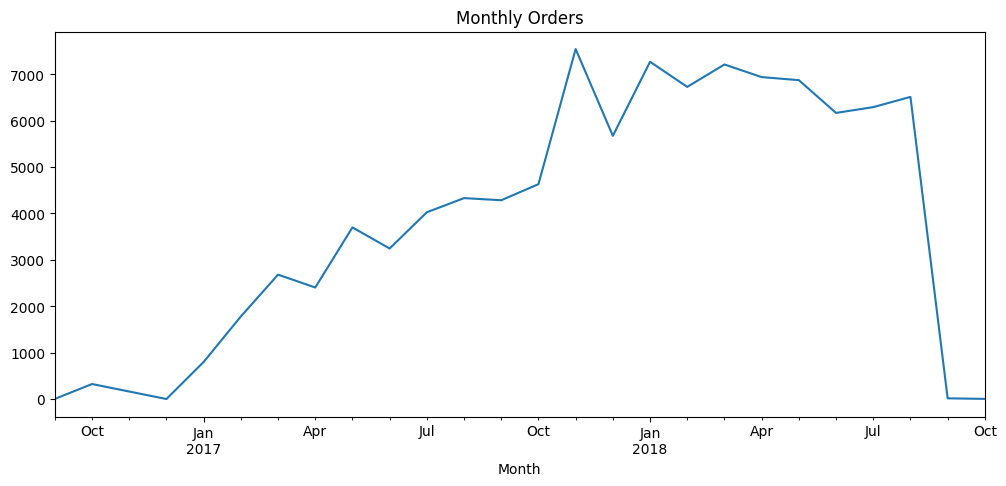

In [ ]:
orders.groupby("Month").size().plot(
    figsize=(12,5),
    title="Monthly Orders"
)

Payment Method Distribution

<Axes: title={'center': 'Payment Methods'}, xlabel='payment_type'>

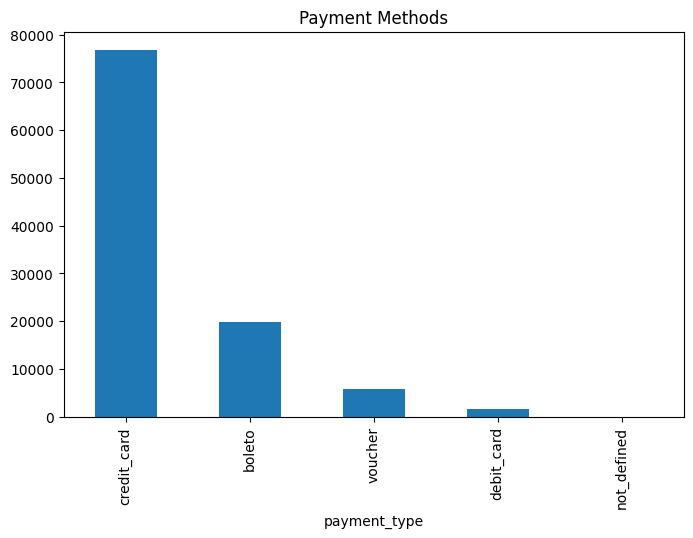

In [ ]:
payments["payment_type"].value_counts().plot(
    kind="bar",
    figsize=(8,5),
    title="Payment Methods"
)

Review Score Distribution

<Axes: title={'center': 'Review Scores'}, xlabel='review_score'>

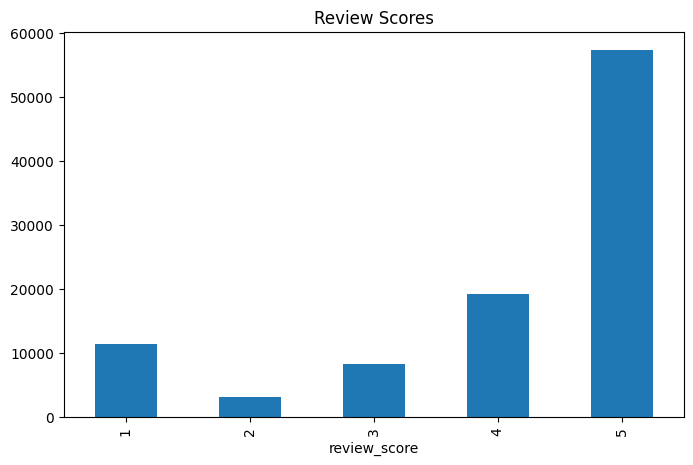

In [ ]:
reviews["review_score"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(8,5),
    title="Review Scores"
)

Revenue by Payment Type

<Axes: title={'center': 'Revenue by Payment Type'}, xlabel='payment_type'>

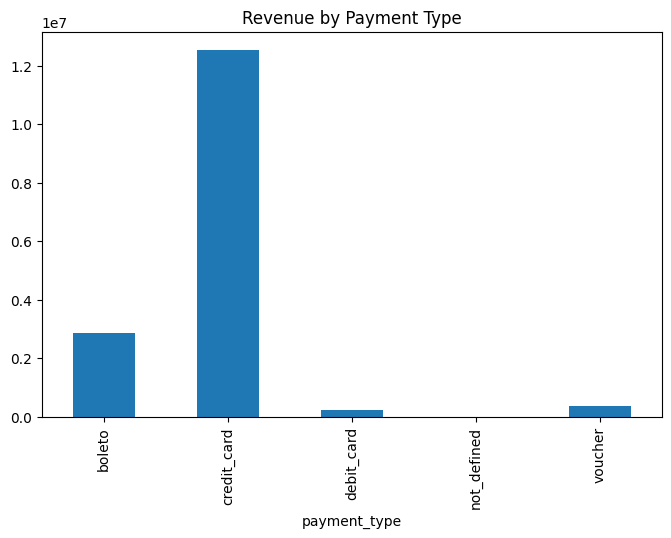

In [ ]:
payment_analysis = payments.groupby("payment_type")["payment_value"].sum()
payment_analysis.plot(
    kind="bar",
    figsize=(8,5),
    title="Revenue by Payment Type"
)

#Revenue Heatmap (Month × Product Category)

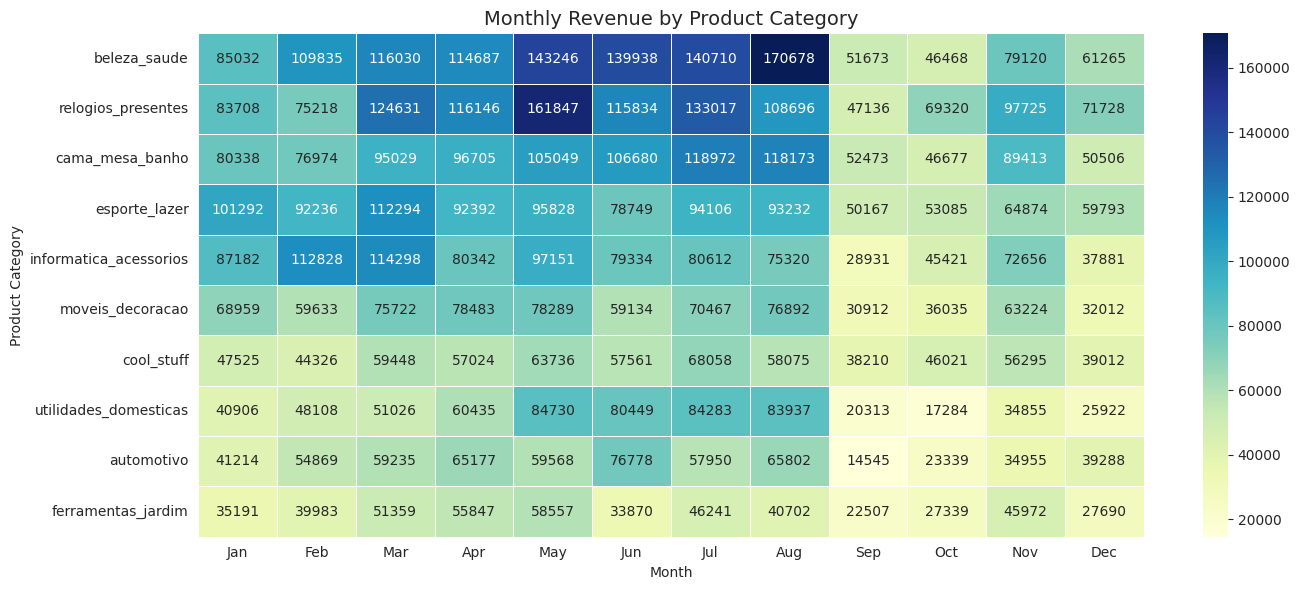

In [ ]:
# Merge required tables
revenue_df = order_items.merge(products, on='product_id')
revenue_df = revenue_df.merge(orders[['order_id', 'order_purchase_timestamp']], on='order_id')

# Convert timestamp
revenue_df['order_purchase_timestamp'] = pd.to_datetime(revenue_df['order_purchase_timestamp'])

# Extract month
revenue_df['Month'] = revenue_df['order_purchase_timestamp'].dt.strftime('%b')

# Revenue by month and category
heatmap_data = revenue_df.pivot_table(
    values='price',
    index='product_category_name',
    columns='Month',
    aggfunc='sum',
    fill_value=0
)

# Order months correctly
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
heatmap_data = heatmap_data.reindex(columns=months)

# Top 10 categories by revenue
top_categories = revenue_df.groupby('product_category_name')['price'].sum().nlargest(10).index
heatmap_data = heatmap_data.loc[top_categories]

plt.figure(figsize=(14, 6))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    annot=True,
    fmt=".0f",
    linewidths=0.5
)

plt.title("Monthly Revenue by Product Category", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Product Category")
plt.tight_layout()

plt.show()

#Delivery Delay vs Review Score

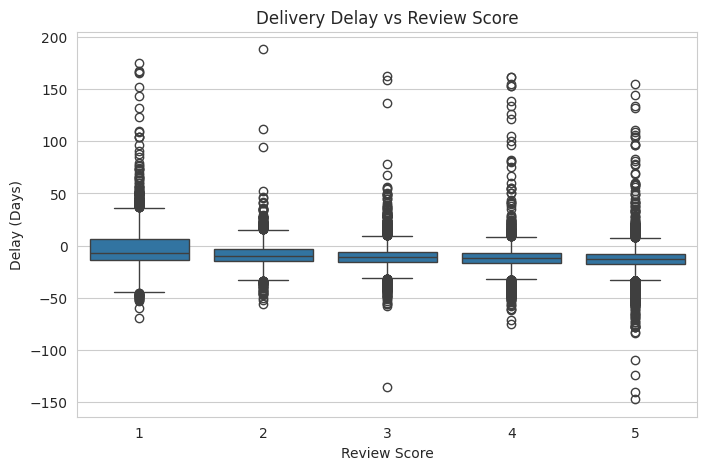

In [ ]:
# Merge orders and reviews
delay_df = orders.merge(reviews[['order_id','review_score']], on='order_id')

# Convert dates
delay_df['order_delivered_customer_date'] = pd.to_datetime(delay_df['order_delivered_customer_date'])
delay_df['order_estimated_delivery_date'] = pd.to_datetime(delay_df['order_estimated_delivery_date'])

# Delay calculation
delay_df['Delivery_Delay'] = (
    delay_df['order_delivered_customer_date'] -
    delay_df['order_estimated_delivery_date']
).dt.days

delay_df = delay_df.dropna(subset=['Delivery_Delay'])

plt.figure(figsize=(8,5))
sns.boxplot(data=delay_df,
            x='review_score',
            y='Delivery_Delay')

plt.title("Delivery Delay vs Review Score")
plt.xlabel("Review Score")
plt.ylabel("Delay (Days)")
plt.show()

#State-wise Revenue & Average Rating

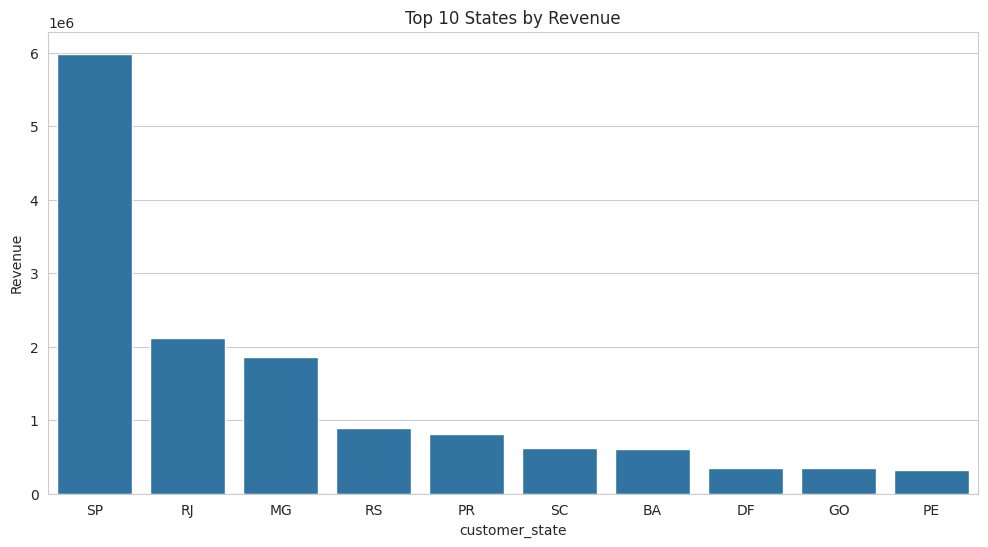

In [ ]:
# Merge all required tables
state_df = orders.merge(customers[['customer_id','customer_state']], on='customer_id')
state_df = state_df.merge(payments[['order_id','payment_value']], on='order_id')
state_df = state_df.merge(reviews[['order_id','review_score']], on='order_id')

summary = state_df.groupby('customer_state').agg(
    Revenue=('payment_value','sum'),
    Avg_Rating=('review_score','mean'),
    Orders=('order_id','nunique')
).sort_values(by='Revenue', ascending=False)

summary.head(10)
plt.figure(figsize=(12,6))
sns.barplot(
    data=summary.head(10).reset_index(),
    x='customer_state',
    y='Revenue'
)

plt.title("Top 10 States by Revenue")
plt.show()

#Pareto Analysis (80/20 Rule)

/tmp/ipykernel_1116/643216482.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


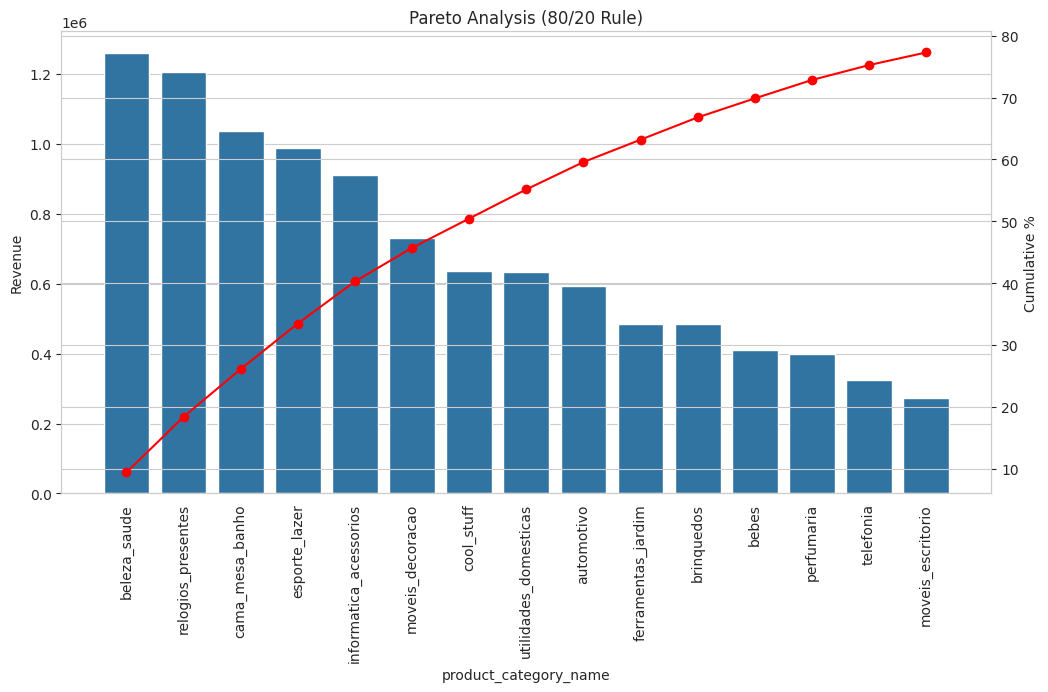

In [ ]:
pareto = order_items.merge(products,on='product_id')

pareto = pareto.groupby('product_category_name')['price'].sum().sort_values(ascending=False)

pareto = pareto.reset_index()

pareto['Cumulative Revenue'] = pareto['price'].cumsum()
pareto['Cumulative %'] = 100 * pareto['Cumulative Revenue'] / pareto['price'].sum()
fig, ax = plt.subplots(figsize=(12,6))

sns.barplot(
    data=pareto.head(15),
    x='product_category_name',
    y='price',
    ax=ax
)

ax2 = ax.twinx()

ax2.plot(
    pareto.head(15)['Cumulative %'],
    color='red',
    marker='o'
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

ax.set_ylabel("Revenue")
ax2.set_ylabel("Cumulative %")

plt.title("Pareto Analysis (80/20 Rule)")
plt.show()